In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
nbaseason_df = pd.read_csv('./data/nbaseason_cleaned.csv')
nbaseason_df.head()

,teamstatspk,Team,win_percentage,Min,points,field_goals_made,field_goals_attempted,field_goal_percentage,three_pointers_made,three_pointers_attempted,three_point_percentage,free_throws_made,free_throw_attempted,free_throw_percentage,season,three_point_shooting_volume,three_point_total_contribution
0,0,Boston Celtics,0.780,3966,9887,3601,7396,48.7,1351,3482,38.8,1334,1654,80.7,2023-24,0.470795,0.409932
1,1,Denver Nuggets,0.695,3941,9418,3610,7279,49.6,958,2560,37.4,1240,1628,76.2,2023-24,0.351697,0.305160
2,2,Oklahoma City Thunder,0.695,3961,9847,3653,7324,49.9,1090,2805,38.9,1451,1759,82.5,2023-24,0.382987,0.332081
3,3,Minnesota Timberwolves,0.683,3961,9264,3383,6974,48.5,1037,2681,38.7,1461,1881,77.7,2023-24,0.384428,0.335816
4,4,LA Clippers,0.622,3941,9481,3473,7108,48.9,1036,2719,38.1,1499,1817,82.5,2023-24,0.382527,0.327814


### Regular season exploratory data analysis ###

#### Single-column profiling ####
We perform single-column profiling to understand data quality, cardinalities, and distributions of numeric columns relevant to our analysis. 

Cardinalities and basic metadata:

In [7]:
key_columns = ['win_percentage', 'three_point_percentage', 
               'three_point_shooting_volume', 'three_point_total_contribution',
               'field_goal_percentage', 'free_throw_percentage']

print(pd.DataFrame({
    'Unique Values': nbaseason_df[key_columns].nunique(),
    'Min': nbaseason_df[key_columns].min(),
    'Max': nbaseason_df[key_columns].max(),
    'Mean': nbaseason_df[key_columns].mean().round(4),
    'Median': nbaseason_df[key_columns].median().round(4),
    'Std Dev': nbaseason_df[key_columns].std().round(4)
}))

                                Unique Values        Min        Max     Mean  \
win_percentage                            117   0.106000   0.890000   0.4998   
three_point_percentage                     97  27.800000  41.600000  35.5884   
three_point_shooting_volume               716   0.100888   0.519475   0.2701   
three_point_total_contribution            715   0.086047   0.431281   0.2348   
field_goal_percentage                      89  40.800000  50.700000  45.5737   
free_throw_percentage                     144  66.000000  83.900000  76.1989   

                                 Median  Std Dev  
win_percentage                   0.5120   0.1489  
three_point_percentage          35.5000   1.8942  
three_point_shooting_volume      0.2519   0.0890  
three_point_total_contribution   0.2243   0.0747  
field_goal_percentage           45.5000   1.6863  
free_throw_percentage           76.3000   3.0030  


Data types and value patterns:

- All percentage columns are stored as floats in expected ranges (0–1 or 0–100 scale).
- 'season' follows consistent "YYYY-YY" pattern.
- 'Team' is categorical with unique teams.
- No mixed data types or format anomalies detected.

Numeric Distributions:

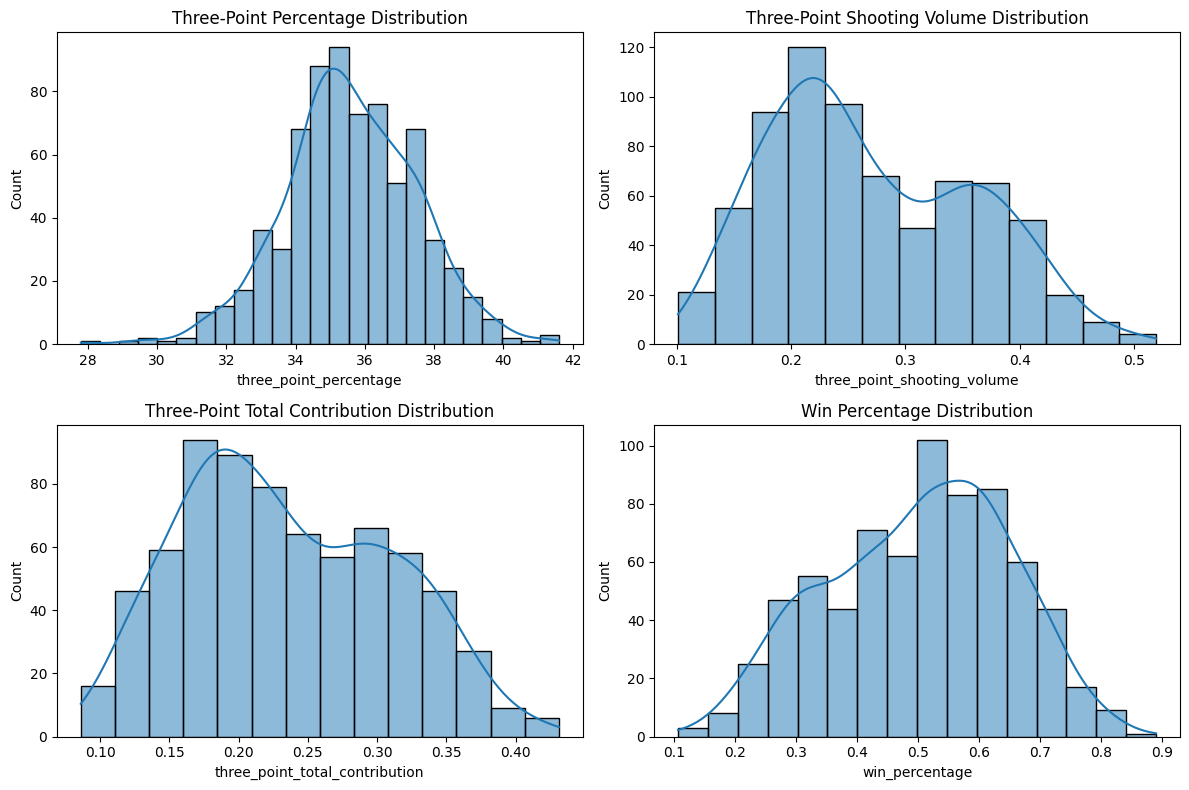

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(nbaseason_df['three_point_percentage'], kde=True, ax=axes[0,0])
axes[0,0].set_title('Three-Point Percentage Distribution')

sns.histplot(nbaseason_df['three_point_shooting_volume'], kde=True, ax=axes[0,1])
axes[0,1].set_title('Three-Point Shooting Volume Distribution')

sns.histplot(nbaseason_df['three_point_total_contribution'], kde=True, ax=axes[1,0])
axes[1,0].set_title('Three-Point Total Contribution Distribution')

sns.histplot(nbaseason_df['win_percentage'], kde=True, ax=axes[1,1])
axes[1,1].set_title('Win Percentage Distribution')

plt.tight_layout()
plt.show()

### 1) Temporal trend: How has the relation of 3-pt shooting & success changed over time? ###
We group the seasonal data into 4-year buckets and conduct regression analysis over time:

<Figure size 1200x800 with 0 Axes>

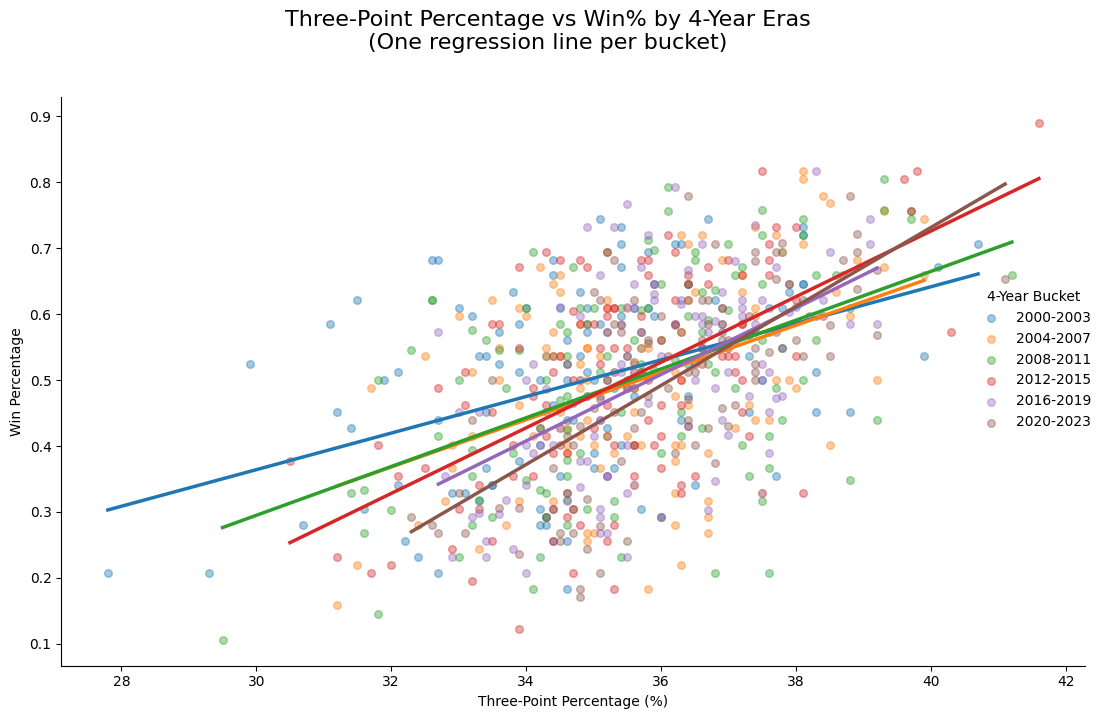

In [ ]:
# Extract the starting year from the season column (e.g., "2023-24" → 2023)
nbaseason_df['year'] = nbaseason_df['season'].str.split('-').str[0].astype(int)
# Create 4-year buckets (2000-2003, 2004-2007, ..., 2020-2023)
nbaseason_df['year_bucket'] = (nbaseason_df['year'] // 4 * 4).astype(str) + '-' + \
                              ((nbaseason_df['year'] // 4 * 4) + 3).astype(str)
# Make the buckets ordered chronologically in the legend
bucket_order = sorted(nbaseason_df['year_bucket'].unique())
nbaseason_df['year_bucket'] = pd.Categorical(nbaseason_df['year_bucket'], 
                                             categories=bucket_order, 
                                             ordered=True)
# Reusable function to make the plot for any 3PT metric
def plot_3pt_vs_win(metric_col, title_suffix):
    plt.figure(figsize=(12, 8))
    g = sns.lmplot(
        data=nbaseason_df,
        x=metric_col,
        y='win_percentage',
        hue='year_bucket',
        ci=None,
        scatter_kws={'alpha': 0.4, 's': 30},
        line_kws={'linewidth': 2.5},
        height=7,
        aspect=1.4,
        palette='tab10'
    )
    g.set_axis_labels(f'{title_suffix} (%)' if 'percentage' in metric_col else title_suffix.replace('_', ' ').title(),
                      'Win Percentage')
    g.fig.suptitle(f'{title_suffix} vs Win% by 4-Year Eras\n(One regression line per bucket)', 
                   y=1.02, fontsize=16)
    g.legend.set_title('4-Year Bucket')
    plt.tight_layout()
    plt.show()
plot_3pt_vs_win('three_point_percentage', 'Three-Point Percentage')

We observe that the regression lines over time have consecutively become steeper in recent years, suggesting that 3PT% has become a stronger predictor of win%. To investigate which specific aspect of 3PT shooting leads to success, we then create similar graphs each for 3PT shooting volume and 3PT total contribution.

<Figure size 1200x800 with 0 Axes>

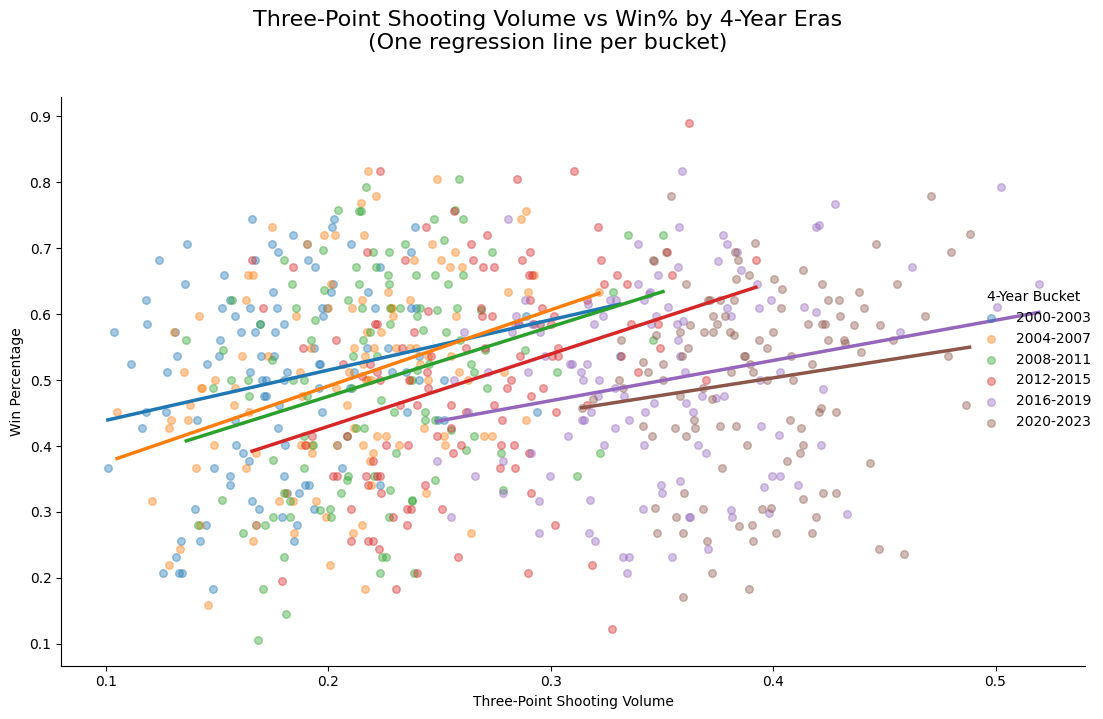

<Figure size 1200x800 with 0 Axes>

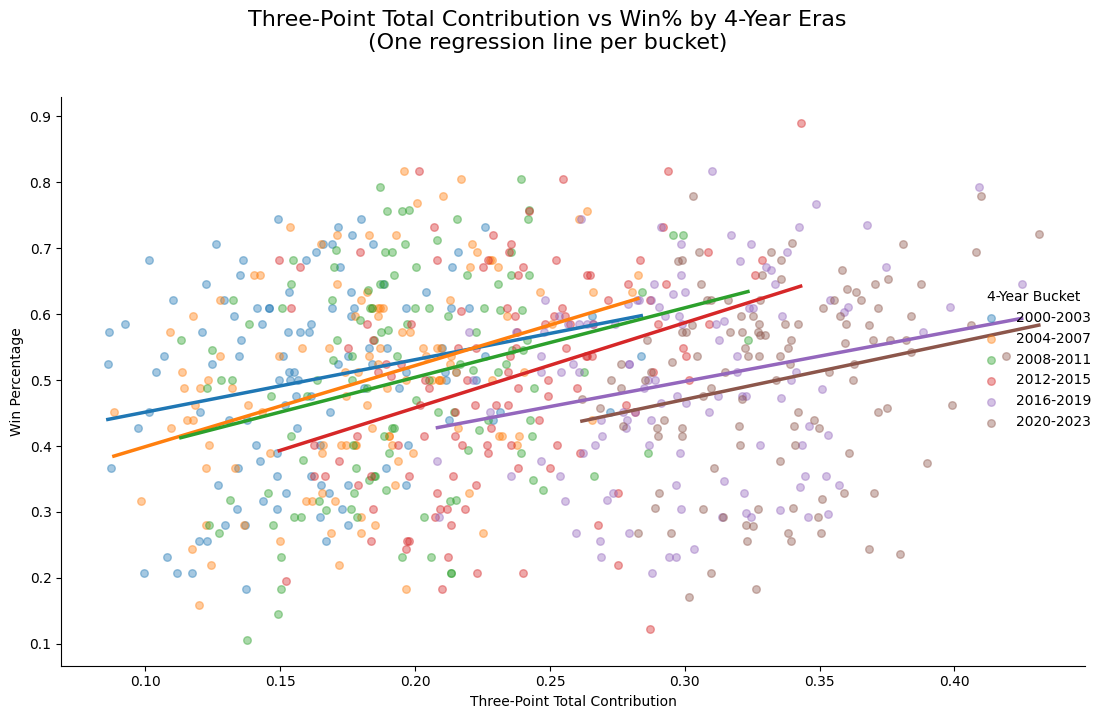

In [ ]:
plot_3pt_vs_win('three_point_shooting_volume', 'Three-Point Shooting Volume')
plot_3pt_vs_win('three_point_total_contribution', 'Three-Point Total Contribution')

Quantitative analysis: For each aspect of 3PT shooting, for each bucket, we compare their slope and R^2 values, while noting whether the p-value indicates a significant result.

In [ ]:
import statsmodels.formula.api as smf

metrics = ['three_point_percentage', 'three_point_shooting_volume', 'three_point_total_contribution']
results = []

for metric in metrics:
    for bucket in nbaseason_df['year_bucket'].cat.categories:
        subset = nbaseason_df[nbaseason_df['year_bucket'] == bucket]
        if len(subset) < 5: continue  # skip tiny buckets if any
        
        model = smf.ols(f'win_percentage ~ {metric}', data=subset).fit()
        slope = model.params[metric]
        r2 = model.rsquared
        pval = model.pvalues[metric]
        
        results.append({
            'Metric': metric.replace('_', ' ').title(),
            'Bucket': bucket,
            'Slope': round(slope, 4),
            'R²': round(r2, 3),
            'p-value': round(pval, 4),
            'Significant': pval < 0.05
        })

# Show results as a table
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                        Metric    Bucket  Slope    R²  p-value  Significant
        Three Point Percentage 2000-2003 0.0278 0.187   0.0000         True
        Three Point Percentage 2004-2007 0.0358 0.198   0.0000         True
        Three Point Percentage 2008-2011 0.0370 0.224   0.0000         True
        Three Point Percentage 2012-2015 0.0497 0.344   0.0000         True
        Three Point Percentage 2016-2019 0.0504 0.267   0.0000         True
        Three Point Percentage 2020-2023 0.0599 0.483   0.0000         True
   Three Point Shooting Volume 2000-2003 0.7628 0.048   0.0182         True
   Three Point Shooting Volume 2004-2007 1.1558 0.127   0.0001         True
   Three Point Shooting Volume 2008-2011 1.0570 0.079   0.0018         True
   Three Point Shooting Volume 2012-2015 1.0975 0.103   0.0003         True
   Three Point Shooting Volume 2016-2019 0.6105 0.049   0.0154         True
   Three Point Shooting Volume 2020-2023 0.5272 0.020   0.1218        False
Three Point 

Findings: We find that the slopes and R^2 values for both 3PT shooting volume and 3PT total contribution do not have any consistent trend over time. Only the 3PT percentage shows a rising slope every year, with a generally increasing R^2 value. The rising slope suggests that overall 3PT percentage has become more important for winning and the rising R^2 value suggests that 3PT percentage explains more of the variance in win percentage now.

### 2) Multivariate Regression: controlling for confounding variables ###
We investigate whether the 3PT metrics still matter after accounting for other obvious drivers of team success (confounding variables) like field goal percentage and free throw percentage. We observe the isolated effect of 3PT shooting after removing the influence of other shooting variables.

In [ ]:
print("=== SECTION 2: MULTIVARIATE ANALYSIS ===\n")
print("Controlling for field_goal_percentage and free_throw_percentage\n")

metrics = ['three_point_percentage', 'three_point_shooting_volume', 'three_point_total_contribution']

results = []

for metric in metrics:
    # Run one multivariate model per 3PT metric
    formula = f'win_percentage ~ {metric} + field_goal_percentage + free_throw_percentage'
    model = smf.ols(formula, data=nbaseason_df).fit()
    
    print(f"\nModel using: {metric.replace('_', ' ').title()}")
    print(f"R² = {model.rsquared:.3f} | Adjusted R² = {model.rsquared_adj:.3f}")
    
    # Coefficient table
    print("Coefficients (effect on win_percentage while holding other variables constant):")
    for var in model.params.index:
        coeff = model.params[var]
        pval = model.pvalues[var]
        sig = "(highly significant)" if pval < 0.01 else "(moderately significant)" if pval < 0.05 else "(slightly significant)" if pval < 0.10 else ""
        print(f"  {var:30} : {coeff:8.4f}  (p = {pval:.4f}){sig}")
    
    results.append({
        'Metric': metric.replace('_', ' ').title(),
        'Coefficient': round(model.params[metric], 4),
        'p_value': round(model.pvalues[metric], 4),
        'R2': round(model.rsquared, 3)
    })

# Summary table
print("\n" + "="*60)
print("SUMMARY TABLE - Independent Effect of Each 3PT Metric")
print("="*60)
summary_df = pd.DataFrame(results)
print(summary_df.to_string(index=False))

=== SECTION 2: MULTIVARIATE ANALYSIS ===

Controlling for field_goal_percentage and free_throw_percentage


Model using: Three Point Percentage
R² = 0.354 | Adjusted R² = 0.352
Coefficients (effect on win_percentage while holding other variables constant):
  Intercept                      :  -1.7937  (p = 0.0000)(highly significant)
  three_point_percentage         :   0.0230  (p = 0.0000)(highly significant)
  field_goal_percentage          :   0.0341  (p = 0.0000)(highly significant)
  free_throw_percentage          :  -0.0010  (p = 0.5126)

Model using: Three Point Shooting Volume
R² = 0.304 | Adjusted R² = 0.301
Coefficients (effect on win_percentage while holding other variables constant):
  Intercept                      :  -1.8846  (p = 0.0000)(highly significant)
  three_point_shooting_volume    :  -0.1431  (p = 0.0124)(moderately significant)
  field_goal_percentage          :   0.0500  (p = 0.0000)(highly significant)
  free_throw_percentage          :   0.0019  (p = 0.2476)


Findings: After controlling for confounders, three-point shooting demonstrates an independent effect on team win percentage. A 1% increase in 3PT percentage is associated with a 2.3% higher win rate (p < 0.001), indicating that 3PT accuracy has a meaningful positive impact beyond shooting efficiency. 

In contrast, 3PT shooting volume shows a negative association (-0.143, p = 0.012), suggesting that higher volume without strong accuracy may actually hurt performance. 3PT total contribution also has a negative relationship (-0.118, p = 0.084). Overall, these multivariate results (R² ≈ 0.30–0.35) confirm that 3PT accuracy, rather than volume or contribution alone, is the key driver of success when other shooting efficiencies are held constant.